In [1]:
import os
os.environ["HF_HOME"] = "D:/huggingface_cache"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from datasets import load_dataset
import pandas as pd

print("Loading Polyvore...")
ds_poly = load_dataset("Marqo/polyvore", split="data")
df_poly = ds_poly.remove_columns(["image"]).to_pandas()

print(f"Total rows: {len(df_poly)}")
print(f"Columns: {df_poly.columns.tolist()}")
print(f"\nSample rows:")
print(df_poly.head(10))

# Extract outfit ID and position
df_poly["outfit_id"] = df_poly["item_ID"].str.rsplit("_", n=1).str[0]
df_poly["position"]  = df_poly["item_ID"].str.rsplit("_", n=1).str[1]

print(f"\nUnique outfits: {df_poly['outfit_id'].nunique()}")
print(f"Unique items: {df_poly['item_ID'].nunique()}")
print(f"\nTop categories:")
print(df_poly["category"].value_counts().head(20))

c:\Users\Ramya Oli\anaconda3\envs\outfit_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Polyvore...


Total rows: 94096
Columns: ['category', 'text', 'item_ID']

Sample rows:
       category                                           text      item_ID
0   Day Dresses                    tibi knit long sleeve dress  100002074_1
1         Boots       michael kors leather over-the-knee boots  100002074_2
2      Handbags  givenchy leather medium antigona duffel black  100002074_3
3    Sunglasses      bottega veneta acetate leather sunglasses  100002074_4
4  Floral Decor                              pier imports stem  100002074_5
5         Coats                                   miranda coat  100002074_7
6       Blazers                            three pocket blazer  100010727_1
7  Skinny Jeans                           givenchy skinny jean  100010727_2
8       Watches      guess black silver-tone chronograph watch  100010727_4
9    Sunglasses           ray-ban original wayfarer sunglasses  100010727_5

Unique outfits: 21587
Unique items: 94096

Top categories:
category
Earrings              

In [2]:
# Define which Polyvore categories are tops and bottoms
TOP_CATEGORIES = [
    "Tops", "T-Shirts", "Blouses", "Sweaters", "Sweatshirts",
    "Tank Tops", "Men's Shirts", "Blazers", "Jackets", "Coats",
    "Vests", "Intimates"
]

BOTTOM_CATEGORIES = [
    "Skinny Jeans", "Boyfriend Jeans", "Shorts", "Skirts",
    "Pants", "Leggings", "Joggers", "Trousers", "Jeans",
    "Day Dresses", "Rompers"
]

df_poly["garment_type"] = None
df_poly.loc[df_poly["category"].isin(TOP_CATEGORIES), "garment_type"]    = "top"
df_poly.loc[df_poly["category"].isin(BOTTOM_CATEGORIES), "garment_type"] = "bottom"

# Keep only tops and bottoms
df_poly_filtered = df_poly[df_poly["garment_type"].notna()].copy()

print(f"After filtering: {len(df_poly_filtered)} items")
print(df_poly_filtered["garment_type"].value_counts())
print(f"\nUnique outfits with tops/bottoms: {df_poly_filtered['outfit_id'].nunique()}")

After filtering: 22662 items
garment_type
top       14543
bottom     8119
Name: count, dtype: int64

Unique outfits with tops/bottoms: 14988


In [3]:
import random
random.seed(42)

pairs = []
seen  = set()

# Group by outfit
outfit_groups = df_poly_filtered.groupby("outfit_id")

# Positive pairs — top + bottom from SAME outfit
for outfit_id, group in outfit_groups:
    tops    = group[group["garment_type"] == "top"]["item_ID"].tolist()
    bottoms = group[group["garment_type"] == "bottom"]["item_ID"].tolist()
    
    if len(tops) == 0 or len(bottoms) == 0:
        continue
    
    for top in tops:
        for bottom in bottoms:
            pair_id = (top, bottom)
            if pair_id in seen:
                continue
            seen.add(pair_id)
            pairs.append({
                "item_A": top,
                "item_B": bottom,
                "label":  1   # REAL compatible pair
            })

print(f"Positive pairs created: {len(pairs)}")

# Negative pairs — top from one outfit + bottom from DIFFERENT outfit
all_tops    = df_poly_filtered[df_poly_filtered["garment_type"] == "top"]["item_ID"].tolist()
all_bottoms = df_poly_filtered[df_poly_filtered["garment_type"] == "bottom"]["item_ID"].tolist()

# Build outfit lookup for fast checking
item_to_outfit = dict(zip(df_poly_filtered["item_ID"], df_poly_filtered["outfit_id"]))

neg_count    = 0
neg_attempts = 0
target_negs  = len(pairs)  # equal positive and negative

while neg_count < target_negs:
    neg_attempts += 1
    if neg_attempts > target_negs * 20:
        print(f"Could only make {neg_count} negative pairs")
        break
    
    top    = random.choice(all_tops)
    bottom = random.choice(all_bottoms)
    
    # Make sure they're from DIFFERENT outfits
    if item_to_outfit[top] == item_to_outfit[bottom]:
        continue
    
    pair_id = (top, bottom)
    if pair_id in seen:
        continue
    
    seen.add(pair_id)
    pairs.append({
        "item_A": top,
        "item_B": bottom,
        "label":  0   # REAL incompatible pair
    })
    neg_count += 1

pairs_df_poly = pd.DataFrame(pairs)
print(f"\nTotal pairs: {len(pairs_df_poly)}")
print(f"Positive: {len(pairs_df_poly[pairs_df_poly['label'] == 1])}")
print(f"Negative: {len(pairs_df_poly[pairs_df_poly['label'] == 0])}")

Positive pairs created: 5969

Total pairs: 11938
Positive: 5969
Negative: 5969


In [4]:
# Check if images exist
ds_poly = load_dataset("Marqo/polyvore", split="data")
print(ds_poly.column_names)
print(ds_poly[0])

['image', 'category', 'text', 'item_ID']
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=274x400 at 0x22B6EFF8250>, 'category': 'Day Dresses', 'text': 'tibi knit long sleeve dress', 'item_ID': '100002074_1'}


In [5]:
import open_clip
import torch
from PIL import Image
import io
import numpy as np

# Load FashionCLIP
print("Loading FashionCLIP...")
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    'hf-hub:Marqo/marqo-fashionSigLIP'
)
clip_model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clip_model = clip_model.to(device)
print(f"FashionCLIP loaded on {device}")

Loading FashionCLIP...
FashionCLIP loaded on cuda


# Get unique item IDs needed
unique_ids_needed = set(
    pairs_df_poly["item_A"].tolist() + 
    pairs_df_poly["item_B"].tolist()
)
print(f"Unique items needed: {len(unique_ids_needed)}")

# Filter dataset to only needed items
ds_poly_filtered = ds_poly.filter(
    lambda row: row["item_ID"] in unique_ids_needed
)
print(f"Items to extract: {len(ds_poly_filtered)}")

# Extract features
feature_dict_poly = {}
batch_size = 32
failed = 0

for start in range(0, len(ds_poly_filtered), batch_size):
    batch        = ds_poly_filtered[start : start + batch_size]
    batch_tensors = []
    batch_ids     = []
    
    for i in range(len(batch["item_ID"])):
        try:
            img    = batch["image"][i]
            if img.mode != "RGB":
                img = img.convert("RGB")
            tensor = preprocess(img)
            batch_tensors.append(tensor)
            batch_ids.append(batch["item_ID"][i])
        except:
            failed += 1
            continue
    
    if len(batch_tensors) == 0:
        continue
    
    batch_tensor = torch.stack(batch_tensors).to(device)
    
    with torch.no_grad():
        features = clip_model.encode_image(batch_tensor)
        features = features / features.norm(dim=-1, keepdim=True)  # normalize
    
    for i, item_id in enumerate(batch_ids):
        feature_dict_poly[item_id] = features[i].cpu().numpy()
    
    if (start // batch_size) % 50 == 0:
        print(f"Extracted {len(feature_dict_poly)}/{len(ds_poly_filtered)} | Failed: {failed}")

np.save("D:/feature_dict_polyvore.npy", feature_dict_poly)
print(f"Done! Extracted: {len(feature_dict_poly)} | Failed: {failed}")

In [7]:
feature_dict_poly = np.load("D:/feature_dict_polyvore.npy", allow_pickle=True).item()
print("Total extracted features:", len(feature_dict_poly))

sample_id = list(feature_dict_poly.keys())[0]
sample_vec = feature_dict_poly[sample_id]

print("Sample ID:", sample_id)
print("Vector shape:", sample_vec.shape)
print("Vector dtype:", sample_vec.dtype)

Total extracted features: 15264
Sample ID: 100002074_1
Vector shape: (768,)
Vector dtype: float32


In [8]:
pairs_df_poly["item_A"] = pairs_df_poly["item_A"].astype(str)
pairs_df_poly["item_B"] = pairs_df_poly["item_B"].astype(str)

pairs_df_poly["vec_A"] = pairs_df_poly["item_A"].map(feature_dict_poly)
pairs_df_poly["vec_B"] = pairs_df_poly["item_B"].map(feature_dict_poly)

print("Before drop:", len(pairs_df_poly))
print("Missing vec_A:", pairs_df_poly["vec_A"].isna().sum())
print("Missing vec_B:", pairs_df_poly["vec_B"].isna().sum())

pairs_df_poly = pairs_df_poly.dropna(subset=["vec_A", "vec_B"]).copy()

print("After drop:", len(pairs_df_poly))

Before drop: 11938
Missing vec_A: 0
Missing vec_B: 0
After drop: 11938


In [10]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# ── Dataset ──────────────────────────────────────────────────────────────
class PairDataset(Dataset):
    def __init__(self, df):
        self.vec_A  = np.stack(df["vec_A"].values)
        self.vec_B  = np.stack(df["vec_B"].values)
        self.labels = df["label"].values.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.vec_A[idx], dtype=torch.float32),
            torch.tensor(self.vec_B[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

# ── Siamese Network ───────────────────────────────────────────────────────
class SiameseNet(nn.Module):
    def __init__(self, input_dim=768):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
        # Kaiming init
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, a, b):
        emb_a = self.branch(a)
        emb_b = self.branch(b)
        combined = torch.cat([torch.abs(emb_a - emb_b), emb_a * emb_b], dim=1)  # 256-dim
        return self.classifier(combined).squeeze(1)

# ── Train / Val split ─────────────────────────────────────────────────────
train_df, val_df = train_test_split(pairs_df_poly, test_size=0.15, random_state=42, stratify=pairs_df_poly["label"])
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

train_ds = PairDataset(train_df)
val_ds   = PairDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)

# ── Model, loss, optimizer ────────────────────────────────────────────────
model     = SiameseNet(input_dim=768).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=4, factor=0.5)

# ── Training loop ─────────────────────────────────────────────────────────
best_val_loss   = float("inf")
early_stop_pat  = 8
no_improve      = 0
EPOCHS          = 50

for epoch in range(1, EPOCHS + 1):
    # --- train ---
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for a, b, label in train_loader:
        a, b, label = a.to(device), b.to(device), label.to(device)
        optimizer.zero_grad()
        logits = model(a, b)
        loss   = criterion(logits, label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss    += loss.item() * len(label)
        preds          = (torch.sigmoid(logits) > 0.5).float()
        train_correct += (preds == label).sum().item()
        train_total   += len(label)

    # --- val ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for a, b, label in val_loader:
            a, b, label = a.to(device), b.to(device), label.to(device)
            logits = model(a, b)
            loss   = criterion(logits, label)
            val_loss    += loss.item() * len(label)
            preds        = (torch.sigmoid(logits) > 0.5).float()
            val_correct += (preds == label).sum().item()
            val_total   += len(label)

    avg_train_loss = train_loss / train_total
    avg_val_loss   = val_loss   / val_total
    train_acc      = train_correct / train_total
    val_acc        = val_correct   / val_total

    scheduler.step(avg_val_loss)
    print(f"Epoch {epoch:02d} | Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} Acc: {val_acc:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        no_improve    = 0
        torch.save(model.state_dict(), "D:/best_model_polyvore.pth")
        print(f"  ✓ Saved best model (val_loss={best_val_loss:.4f})")
    else:
        no_improve += 1
        if no_improve >= early_stop_pat:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"\nBest val loss: {best_val_loss:.4f}")

Train: 10147 | Val: 1791
Epoch 01 | Train Loss: 0.7505 Acc: 0.5437 | Val Loss: 0.6658 Acc: 0.5857
  ✓ Saved best model (val_loss=0.6658)
Epoch 02 | Train Loss: 0.6821 Acc: 0.5897 | Val Loss: 0.6446 Acc: 0.6125
  ✓ Saved best model (val_loss=0.6446)
Epoch 03 | Train Loss: 0.6441 Acc: 0.6180 | Val Loss: 0.6333 Acc: 0.6421
  ✓ Saved best model (val_loss=0.6333)
Epoch 04 | Train Loss: 0.6228 Acc: 0.6489 | Val Loss: 0.6252 Acc: 0.6533
  ✓ Saved best model (val_loss=0.6252)
Epoch 05 | Train Loss: 0.6009 Acc: 0.6684 | Val Loss: 0.6216 Acc: 0.6588
  ✓ Saved best model (val_loss=0.6216)
Epoch 06 | Train Loss: 0.5846 Acc: 0.6817 | Val Loss: 0.6154 Acc: 0.6644
  ✓ Saved best model (val_loss=0.6154)
Epoch 07 | Train Loss: 0.5652 Acc: 0.6936 | Val Loss: 0.6086 Acc: 0.6734
  ✓ Saved best model (val_loss=0.6086)
Epoch 08 | Train Loss: 0.5528 Acc: 0.7103 | Val Loss: 0.6116 Acc: 0.6739
Epoch 09 | Train Loss: 0.5403 Acc: 0.7224 | Val Loss: 0.6171 Acc: 0.6767
Epoch 10 | Train Loss: 0.5247 Acc: 0.7304 | V

In [11]:
from datasets import load_dataset
import torch
import numpy as np
import pandas as pd

# Load Fashion200K from HuggingFace
print("Loading Fashion200K...")
ds_f200k = load_dataset("Marqo/fashion200k", split="data")
print(f"Total items: {len(ds_f200k)}")

# Load subset CSV
df_subset = pd.read_csv("D:/fashion200k_subset.csv")
subset_ids = set(df_subset["item_ID"].astype(str).tolist())
print(f"Subset items to extract: {len(subset_ids)}")

# Check what the actual item ID column is called in HF dataset
print("HF dataset columns:", ds_f200k.column_names)
print("Sample HF item:", ds_f200k[0]["item_ID"] if "item_ID" in ds_f200k.column_names else "check column name")

Loading Fashion200K...
Total items: 201624
Subset items to extract: 72333
HF dataset columns: ['image', 'category1', 'category2', 'category3', 'text', 'item_ID']
Sample HF item: 51727804_0


In [17]:
from datasets import load_dataset
import torch
import numpy as np

# Load Fashion200K from HuggingFace
print("Loading Fashion200K...")
ds_f200k = load_dataset("Marqo/fashion200k", split="data")
print(f"Total items: {len(ds_f200k)}")

# Load your subset CSV to know which item_IDs to keep
import pandas as pd
df_subset = pd.read_csv("D:/fashion200k_subset.csv")
subset_ids = set(df_subset["item_ID"].astype(str).tolist())
print(f"Subset items to extract: {len(subset_ids)}")

# Filter HF dataset to only subset items
ds_f200k_filtered = ds_f200k.filter(
    lambda row: str(row["item_ID"]) in subset_ids
)
print(f"Matched in HF dataset: {len(ds_f200k_filtered)}")

# Extract FashionCLIP features
feature_dict_f200k = {}
batch_size = 32
failed = 0

for start in range(0, len(ds_f200k_filtered), batch_size):
    batch         = ds_f200k_filtered[start : start + batch_size]
    batch_tensors = []
    batch_ids     = []

    for i in range(len(batch["item_ID"])):
        try:
            img = batch["image"][i]
            if img.mode != "RGB":
                img = img.convert("RGB")
            tensor = preprocess(img)
            batch_tensors.append(tensor)
            batch_ids.append(str(batch["item_ID"][i]))
        except:
            failed += 1
            continue

    if not batch_tensors:
        continue

    batch_tensor = torch.stack(batch_tensors).to(device)

    with torch.no_grad():
        features = clip_model.encode_image(batch_tensor)
        features = features / features.norm(dim=-1, keepdim=True)

    for i, item_id in enumerate(batch_ids):
        feature_dict_f200k[item_id] = features[i].cpu().numpy()

    if (start // batch_size) % 50 == 0:
        print(f"Extracted {len(feature_dict_f200k)}/{len(ds_f200k_filtered)} | Failed: {failed}")

np.save("D:/feature_dict_f200k_clip.npy", feature_dict_f200k)
print(f"Done! Extracted: {len(feature_dict_f200k)} | Failed: {failed}")

Loading Fashion200K...
Total items: 201624
Subset items to extract: 72333


Filter: 100%|██████████| 201624/201624 [05:46<00:00, 582.46 examples/s]


Matched in HF dataset: 72363
Extracted 32/72363 | Failed: 0
Extracted 1632/72363 | Failed: 0
Extracted 3232/72363 | Failed: 0
Extracted 4830/72363 | Failed: 0
Extracted 6430/72363 | Failed: 0
Extracted 8030/72363 | Failed: 0
Extracted 9630/72363 | Failed: 0
Extracted 11222/72363 | Failed: 0
Extracted 12820/72363 | Failed: 0
Extracted 14415/72363 | Failed: 0
Extracted 16015/72363 | Failed: 0
Extracted 17615/72363 | Failed: 0
Extracted 19214/72363 | Failed: 0
Extracted 20814/72363 | Failed: 0
Extracted 22414/72363 | Failed: 0
Extracted 24014/72363 | Failed: 0
Extracted 25614/72363 | Failed: 0
Extracted 27214/72363 | Failed: 0
Extracted 28814/72363 | Failed: 0
Extracted 30409/72363 | Failed: 0
Extracted 32009/72363 | Failed: 0
Extracted 33609/72363 | Failed: 0
Extracted 35208/72363 | Failed: 0
Extracted 36807/72363 | Failed: 0
Extracted 38407/72363 | Failed: 0
Extracted 40007/72363 | Failed: 0
Extracted 41605/72363 | Failed: 0
Extracted 43205/72363 | Failed: 0
Extracted 44805/72363 | Fail

In [13]:
from datasets import load_dataset
import pandas as pd
import numpy as np

# Reload HF dataset
print("Loading Fashion200K...")
ds_f200k = load_dataset("Marqo/fashion200k", split="data")

# Reload subset IDs
df_subset = pd.read_csv("D:/fashion200k_subset.csv")
subset_ids = set(df_subset["item_ID"].astype(str).tolist())

# Filter (needed for id_to_index and image lookup later)
print("Filtering...")
ds_f200k_filtered = ds_f200k.filter(
    lambda row: str(row["item_ID"]) in subset_ids
)
print(f"Filtered: {len(ds_f200k_filtered)} items")

# Load already extracted features from disk — NO re-extraction
feature_dict_f200k = np.load("D:/feature_dict_f200k_clip.npy", allow_pickle=True).item()
print(f"Features loaded: {len(feature_dict_f200k)} items")

Loading Fashion200K...
Filtering...
Filtered: 72363 items
Features loaded: 72333 items


In [14]:
print("Building ID to index lookup...")
id_to_index = {str(ds_f200k_filtered[i]["item_ID"]): i for i in range(len(ds_f200k_filtered))}
np.save("D:/f200k_id_to_index.npy", id_to_index)
print(f"Done! {len(id_to_index)} items indexed")

Building ID to index lookup...
Done! 72333 items indexed


In [15]:
import faiss
import numpy as np
import pandas as pd

feature_dict_f200k = np.load("D:/feature_dict_f200k_clip.npy", allow_pickle=True).item()
df_subset = pd.read_csv("D:/fashion200k_subset.csv")
df_subset["item_ID"] = df_subset["item_ID"].astype(str)

print(f"Catalog size: {len(feature_dict_f200k)} items")

# Filter to only items we have features for
df_catalog = df_subset[df_subset["item_ID"].isin(feature_dict_f200k.keys())].copy()
print(f"Items with features: {len(df_catalog)}")
print(df_catalog["category1"].value_counts())

Catalog size: 72333 items
Items with features: 72333
category1
dresses    20974
tops       18237
pants      11921
skirts     10668
jackets    10533
Name: count, dtype: int64


In [37]:
TOP_CATS     = ["tops", "jackets"]
BOTTOM_CATS  = ["pants", "skirts"]
DRESS_CATS   = ["dresses"]

df_tops    = df_catalog[df_catalog["category1"].isin(TOP_CATS)].reset_index(drop=True)
df_bottoms = df_catalog[df_catalog["category1"].isin(BOTTOM_CATS)].reset_index(drop=True)
df_dresses = df_catalog[df_catalog["category1"].isin(DRESS_CATS)].reset_index(drop=True)

print(f"Tops: {len(df_tops)}")
print(f"Bottoms: {len(df_bottoms)}")
print(f"Dresses: {len(df_dresses)}")

# Build FAISS index for tops
top_vectors = np.stack([feature_dict_f200k[iid] for iid in df_tops["item_ID"]]).astype("float32")
index_tops  = faiss.IndexFlatIP(768)
index_tops.add(top_vectors)

# Build FAISS index for bottoms
bottom_vectors = np.stack([feature_dict_f200k[iid] for iid in df_bottoms["item_ID"]]).astype("float32")
index_bottoms  = faiss.IndexFlatIP(768)
index_bottoms.add(bottom_vectors)

# Build FAISS index for dresses
dress_vectors = np.stack([feature_dict_f200k[iid] for iid in df_dresses["item_ID"]]).astype("float32")
index_dresses = faiss.IndexFlatIP(768)
index_dresses.add(dress_vectors)

print(f"FAISS tops: {index_tops.ntotal}")
print(f"FAISS bottoms: {index_bottoms.ntotal}")
print(f"FAISS dresses: {index_dresses.ntotal}")

Tops: 28770
Bottoms: 22589
Dresses: 20974
FAISS tops: 28770
FAISS bottoms: 22589
FAISS dresses: 20974


Detected intent: full_outfit


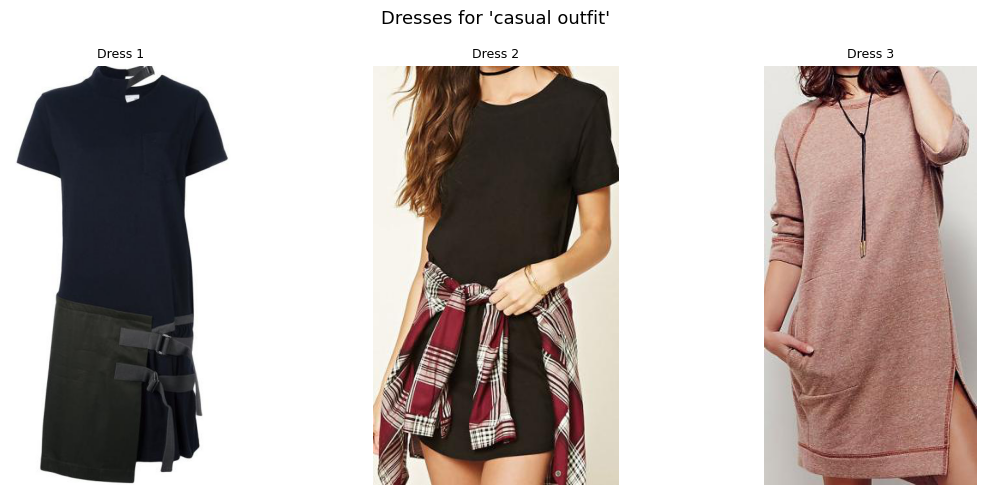

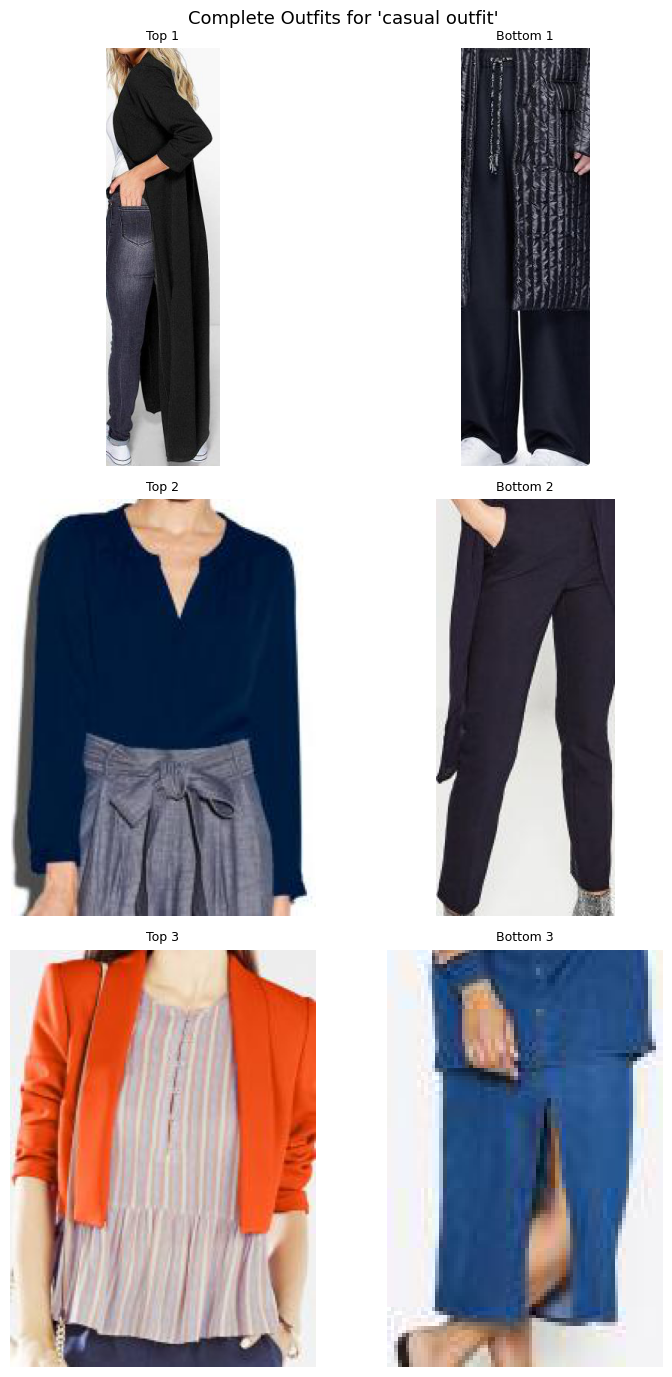

Detected intent: dress


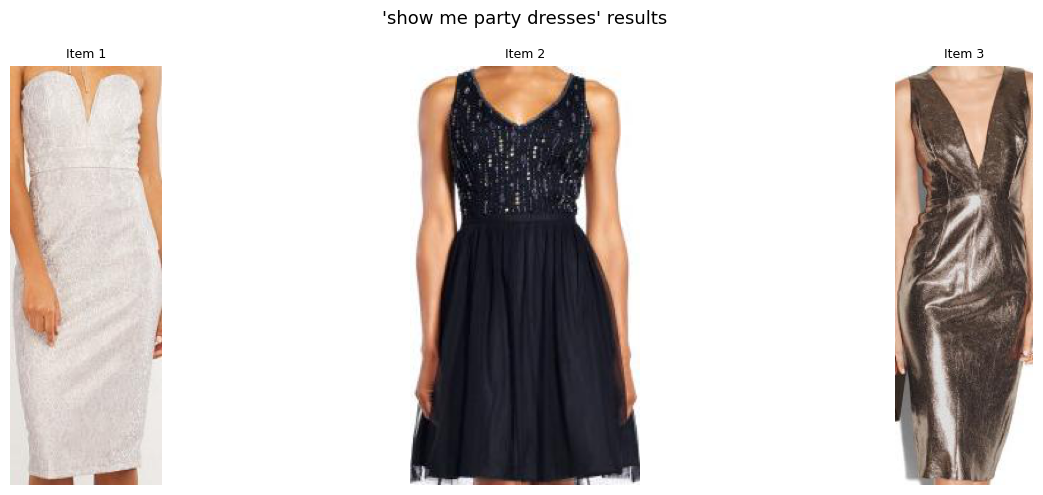

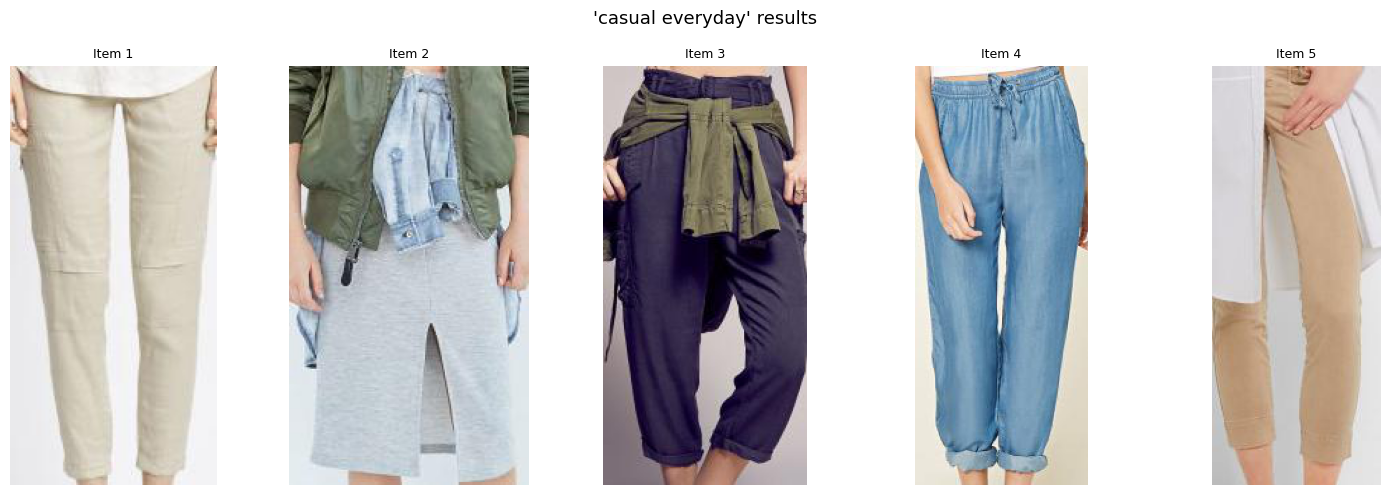

In [44]:
def detect_intent(text):
    """
    Detect if user wants a specific garment type from text
    Returns: "dress", "top", "bottom", or "full_outfit" (default)
    """
    text_lower = text.lower()
    
    if any(word in text_lower for word in ["dress", "gown", "frock"]):
        return "dress"
    elif any(word in text_lower for word in ["top", "shirt", "blouse", "sweater", "jacket"]):
        return "top"
    elif any(word in text_lower for word in ["bottom", "pants", "skirt", "jeans", "trousers"]):
        return "bottom"
    else:
        return "full_outfit"  # default → 3 dresses + 3 complete outfits


def recommend_from_text(text, top_k=3, n_candidates=50):
    """
    Text only → detect intent → return accordingly
    """
    query_vec = get_text_features(text)
    intent    = detect_intent(text)
    print(f"Detected intent: {intent}")

    # ── Dress only ────────────────────────────────────────────────────────
    if intent == "dress":
        _, indices = index_dresses.search(query_vec, top_k + 10)
        ids   = df_dresses.iloc[indices[0]]["item_ID"].tolist()[:top_k]
        imgs  = [get_item_image(iid) for iid in ids]
        meta  = df_dresses.iloc[indices[0]].copy().reset_index(drop=True).head(top_k)
        return {"mode": "dress", "items": imgs, "meta": meta}

    # ── Top only ──────────────────────────────────────────────────────────
    elif intent == "top":
        _, indices = index_tops.search(query_vec, top_k + 10)
        ids   = df_tops.iloc[indices[0]]["item_ID"].tolist()[:top_k]
        imgs  = [get_item_image(iid) for iid in ids]
        meta  = df_tops.iloc[indices[0]].copy().reset_index(drop=True).head(top_k)
        return {"mode": "top", "items": imgs, "meta": meta}

    # ── Bottom only ───────────────────────────────────────────────────────
    elif intent == "bottom":
        _, indices = index_bottoms.search(query_vec, top_k + 10)
        ids   = df_bottoms.iloc[indices[0]]["item_ID"].tolist()[:top_k]
        imgs  = [get_item_image(iid) for iid in ids]
        meta  = df_bottoms.iloc[indices[0]].copy().reset_index(drop=True).head(top_k)
        return {"mode": "bottom", "items": imgs, "meta": meta}

    # ── Full outfit (default) ─────────────────────────────────────────────
    else:
        # Section 1 — Dresses
        _, dress_indices = index_dresses.search(query_vec, top_k)
        dress_ids  = df_dresses.iloc[dress_indices[0]]["item_ID"].tolist()
        dress_imgs = [get_item_image(iid) for iid in dress_ids]
        dress_meta = df_dresses.iloc[dress_indices[0]].copy().reset_index(drop=True)

        # Section 2 — Complete outfits
        _, top_indices = index_tops.search(query_vec, n_candidates)
        top_ids   = df_tops.iloc[top_indices[0]]["item_ID"].tolist()
        top_vecs  = np.stack([feature_dict_f200k[iid] for iid in top_ids]).astype("float32")
        top_meta  = df_tops.iloc[top_indices[0]].copy().reset_index(drop=True)

        _, bot_indices = index_bottoms.search(query_vec, n_candidates)
        bot_ids   = df_bottoms.iloc[bot_indices[0]]["item_ID"].tolist()
        bot_vecs  = np.stack([feature_dict_f200k[iid] for iid in bot_ids]).astype("float32")
        bot_meta  = df_bottoms.iloc[bot_indices[0]].copy().reset_index(drop=True)

        # Score every top vs every bottom
        outfit_pairs = []
        for t_idx in range(len(top_ids)):
            scores       = siamese_score(top_vecs[t_idx], bot_vecs)
            best_bot_idx = np.argmax(scores)
            outfit_pairs.append({
                "top_id":    top_ids[t_idx],
                "bottom_id": bot_ids[best_bot_idx],
                "top_text":  top_meta.iloc[t_idx]["text"],
                "bot_text":  bot_meta.iloc[best_bot_idx]["text"],
                "score":     scores[best_bot_idx]
            })

        # Sort and deduplicate
        outfit_pairs = sorted(outfit_pairs, key=lambda x: x["score"], reverse=True)
        seen_bottoms = set()
        unique_pairs = []
        for pair in outfit_pairs:
            if pair["bottom_id"] not in seen_bottoms:
                seen_bottoms.add(pair["bottom_id"])
                unique_pairs.append(pair)
            if len(unique_pairs) == top_k:
                break

        outfit_imgs = [(get_item_image(p["top_id"]), get_item_image(p["bottom_id"])) for p in unique_pairs]

        return {
            "mode":        "full_outfit",
            "dress_imgs":  dress_imgs,
            "dress_meta":  dress_meta,
            "outfit_imgs": outfit_imgs,
            "outfit_pairs": unique_pairs
        }


def recommend_from_image_and_text(pil_image, text, garment_type="top", top_k=5, n_candidates=50):
    """
    Image + text → always returns compatible opposite category
    garment_type: type of UPLOADED image
        "top"    → returns compatible bottoms
        "bottom" → returns compatible tops
        "dress"  → returns compatible jackets
    """
    image_vec = get_image_features(pil_image)
    text_vec  = get_text_features(text)

    if garment_type == "top":
        search_index = index_bottoms
        search_df    = df_bottoms

    elif garment_type == "bottom":
        search_index = index_tops
        search_df    = df_tops

    elif garment_type == "dress":
        search_df    = df_tops[df_tops["category1"] == "jackets"].reset_index(drop=True)
        jacket_vecs  = np.stack([feature_dict_f200k[iid] for iid in search_df["item_ID"]]).astype("float32")
        search_index = faiss.IndexFlatIP(768)
        search_index.add(jacket_vecs)

    # FAISS with text (mood steers candidates)
    _, cand_indices = search_index.search(text_vec, n_candidates)
    candidate_ids   = search_df.iloc[cand_indices[0]]["item_ID"].tolist()
    candidate_vecs  = np.stack([feature_dict_f200k[iid] for iid in candidate_ids]).astype("float32")
    candidate_meta  = search_df.iloc[cand_indices[0]].copy().reset_index(drop=True)

    # Siamese with image (real compatibility)
    scores = siamese_score(image_vec[0], candidate_vecs)
    candidate_meta["score"] = scores
    candidate_meta = candidate_meta.sort_values("score", ascending=False).head(top_k)

    recommend_images = [get_item_image(iid) for iid in candidate_meta["item_ID"]]
    return {"mode": garment_type, "items": recommend_images, "meta": candidate_meta}


# ── Display helpers ───────────────────────────────────────────────────────
def display_results(result, input_image=None, query_text=""):

    if result["mode"] == "full_outfit":
        # Show dresses
        fig, axes = plt.subplots(1, 3, figsize=(12, 5))
        fig.suptitle(f"Dresses for '{query_text}'", fontsize=13)
        for i, img in enumerate(result["dress_imgs"]):
            axes[i].imshow(img)
            axes[i].set_title(f"Dress {i+1}", fontsize=9)
            axes[i].axis("off")
        plt.tight_layout()
        plt.show()

        # Show complete outfits
        fig, axes = plt.subplots(3, 2, figsize=(8, 14))
        fig.suptitle(f"Complete Outfits for '{query_text}'", fontsize=13)
        for i, (top_img, bot_img) in enumerate(result["outfit_imgs"]):
            axes[i][0].imshow(top_img)
            axes[i][0].set_title(f"Top {i+1}", fontsize=9)
            axes[i][0].axis("off")
            axes[i][1].imshow(bot_img)
            axes[i][1].set_title(f"Bottom {i+1}", fontsize=9)
            axes[i][1].axis("off")
        plt.tight_layout()
        plt.show()

    elif result["mode"] in ["dress", "top", "bottom"]:
        fig, axes = plt.subplots(1, len(result["items"]), figsize=(15, 5))
        fig.suptitle(f"'{query_text}' results", fontsize=13)
        for i, img in enumerate(result["items"]):
            axes[i].imshow(img)
            axes[i].set_title(f"Item {i+1}", fontsize=9)
            axes[i].axis("off")
        plt.tight_layout()
        plt.show()

    elif result["mode"] in ["top", "bottom", "dress"]:
        cols = len(result["items"]) + 1
        fig, axes = plt.subplots(1, cols, figsize=(cols * 3, 5))
        if input_image:
            axes[0].imshow(input_image)
            axes[0].set_title("Your Item", fontsize=9)
            axes[0].axis("off")
        for i, img in enumerate(result["items"]):
            axes[i+1].imshow(img)
            axes[i+1].set_title(f"Rec {i+1}", fontsize=9)
            axes[i+1].axis("off")
        plt.tight_layout()
        plt.show()


# ── Tests ─────────────────────────────────────────────────────────────────
# Test 1 — full outfit from text
result = recommend_from_text("casual outfit")
display_results(result, query_text="casual outfit")

# Test 2 — dress only from text
result = recommend_from_text("show me party dresses")
display_results(result, query_text="show me party dresses")

# Test 3 — image + text
result = recommend_from_image_and_text(my_image, "casual everyday", garment_type="top")
display_results(result, input_image=my_image, query_text="casual everyday")

In [43]:
# Test 1 — Text only
print("="*50)
print("TEST 1: Text only")
print("="*50)
anchor_img, rec_imgs, rec_meta = recommend_from_text(
    "summer chic formal", 
    find_type="bottom"
)
print(rec_meta[["text", "category1", "score"]])

# Display images inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
axes[0].imshow(anchor_img)
axes[0].set_title("Anchor (Top)")
axes[0].axis("off")
for i, img in enumerate(rec_imgs):
    axes[i+1].imshow(img)
    axes[i+1].set_title(f"Rec {i+1}")
    axes[i+1].axis("off")
plt.suptitle("Text Query: 'party outfit with elegant'")
plt.tight_layout()
plt.show()

TEST 1: Text only


TypeError: recommend_from_text() got an unexpected keyword argument 'find_type'

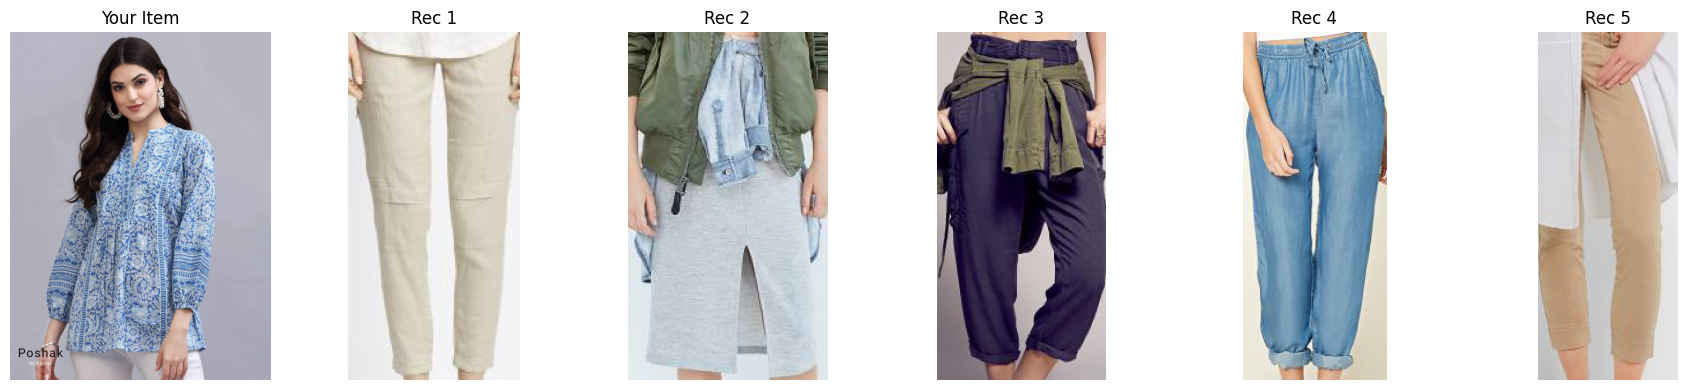

In [40]:
from PIL import Image

# Load your own image
my_image = Image.open(r"C:\Users\Ramya Oli\Downloads\top.webp").convert("RGB") # change path to your image

# If you have a top, find compatible bottoms
rec_imgs, rec_meta = recommend_from_image_and_text(
    my_image,
    text="casual everyday",   # change mood as you like
    garment_type="top"        # change to "bottom" if you're uploading a bottom
)

# Display
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 6, figsize=(18, 4))
axes[0].imshow(my_image)
axes[0].set_title("Your Item")
axes[0].axis("off")
for i, img in enumerate(rec_imgs):
    axes[i+1].imshow(img)
    axes[i+1].set_title(f"Rec {i+1}")
    axes[i+1].axis("off")
plt.tight_layout()
plt.show()

TEST 3: Image + Text
                                                 text category1     score
28  brown suit. the suit consists of a skirt and a...    skirts  0.847173
15  navy blue pencil skirt. the skirt is made of a...    skirts  0.828034
4   gray pencil skirt. the skirt is made of a mate...    skirts  0.825162
10  black pencil skirt. the skirt is made of a mat...    skirts  0.824637
6   gray pencil skirt. the skirt is made of a mate...    skirts  0.822981


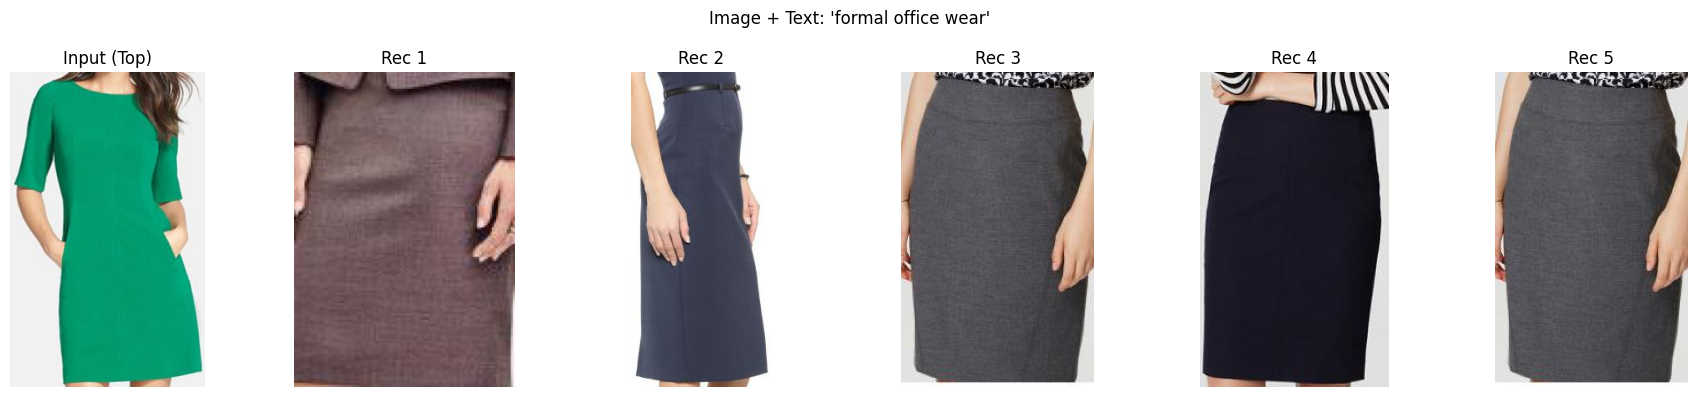

In [41]:
# Test 3 — Image + Text
print("="*50)
print("TEST 3: Image + Text")
print("="*50)

rec_imgs, rec_meta = recommend_from_image_and_text(
    test_image,
    text="formal office wear",
    garment_type="top"
)
print(rec_meta[["text", "category1", "score"]])

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
axes[0].imshow(test_image)
axes[0].set_title("Input (Top)")
axes[0].axis("off")
for i, img in enumerate(rec_imgs):
    axes[i+1].imshow(img)
    axes[i+1].set_title(f"Rec {i+1}")
    axes[i+1].axis("off")
plt.suptitle("Image + Text: 'formal office wear'")
plt.tight_layout()
plt.show()